# Classification workflow
Binary pass/fail models for the student datasets. Processed features feed the classifiers while raw labels provide the G3 target.

In [1]:
# Imports for data handling, plotting, and model evaluation
from pathlib import Path  # filesystem paths
from typing import Dict, List  # type hints for dictionaries/lists

import numpy as np  # numerical arrays and math utilities
import pandas as pd  # tabular data handling
import matplotlib.pyplot as plt  # plotting interface
import seaborn as sns  # statistical visualization helpers

from sklearn.linear_model import LogisticRegression  # linear classifier baseline
from sklearn.ensemble import RandomForestClassifier  # tree-based ensemble classifier
from sklearn.model_selection import train_test_split, cross_val_score  # data splitting and cross-validation
from sklearn.metrics import (
    accuracy_score,  # overall accuracy
    precision_score,  # positive precision
    recall_score,  # positive recall
    f1_score,  # harmonic mean of precision/recall
    roc_auc_score,  # area under ROC
    confusion_matrix,  # confusion matrix counts
    roc_curve,  # ROC curve coordinates
    precision_recall_curve,  # PR curve coordinates
)

## Paths
Centralized project paths for data and report outputs.

In [2]:
# Project directories for data inputs and plot outputs
PROJECT_ROOT = Path().resolve().parent  # repo root (one level up)
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"  # processed feature matrices
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"  # raw CSVs
REPORTS_DIR = PROJECT_ROOT / "reports"  # reports folder
PLOTS_DIR = REPORTS_DIR / "Models" /"Classification"  # classification plot output
PLOTS_DIR.mkdir(parents=True, exist_ok=True)  # ensure plot directory exists

## Data loaders
Helpers to read processed feature matrices and raw CSVs for mat/por.

In [3]:
# Load processed feature matrices and raw CSVs with simple validation
def load_processed(dataset: str) -> pd.DataFrame:  # read processed dataset by key
    path = PROCESSED_DATA_DIR / f"processed_{dataset}.csv"  # build file path
    if not path.exists():  # validate presence
        raise FileNotFoundError(f"File not found: {path}")  # informative error
    return pd.read_csv(path)  # return dataframe


def load_raw(dataset: str) -> pd.DataFrame:  # read raw dataset by key
    if dataset == "mat":  # math dataset
        path = RAW_DATA_DIR / "student-mat.csv"  # math CSV path
    elif dataset == "por":  # Portuguese dataset
        path = RAW_DATA_DIR / "student-por.csv"  # Portuguese CSV path
    else:
        raise ValueError("dataset must be 'mat' or 'por'")  # guard invalid key
    return pd.read_csv(path, sep=";")  # load raw CSV with semicolon separator


## Models
Define the classifier zoo (logistic regression, random forest, optional XGBoost).

In [4]:
# Define candidate classifiers; add XGBoost if available
def get_models() -> Dict[str, object]:  # assemble model dictionary
    models = {
        "LogisticRegression": LogisticRegression(max_iter=500),  # linear baseline
        "RandomForestClassifier": RandomForestClassifier(
            n_estimators=300,  # number of trees
            random_state=42,  # reproducibility
            n_jobs=-1,  # use all cores
        ),
    }

    # Try XGBoost if installed
    try:
        from xgboost import XGBClassifier  # optional boosted trees

        models["XGBClassifier"] = XGBClassifier(
            n_estimators=400,  # trees in ensemble
            max_depth=4,  # tree depth
            learning_rate=0.05,  # shrinkage rate
            subsample=0.9,  # row subsampling
            colsample_bytree=0.9,  # column subsampling
            random_state=42,  # reproducibility
            n_jobs=-1,  # all cores
        )
    except ImportError:
        print("⚠ xgboost not installed. Skipping XGBClassifier.")  # notify absence

    return models  # return model set


## Train and evaluate
Build target from raw G3, fit models, and compute metrics/cross-val for each dataset.

In [5]:
# Train a single model: build binary target, split, fit, and score
def train_single_model(
    df_processed: pd.DataFrame,  # processed features
    df_raw: pd.DataFrame,  # raw data with labels
    model_name: str,  # model identifier
    model,  # estimator instance
    dataset_name: str,  # dataset tag (mat/por)
):
    if "G3" not in df_raw.columns:  # ensure label present
        raise ValueError("G3 column missing in raw dataframe.")  # guard missing target

    y = (df_raw["G3"] >= 10).astype(int)  # build binary target from raw G3
    X = df_processed.drop(columns=["G3"])  # drop label from features

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )  # stratified split

    model.fit(X_train, y_train)  # fit model
    y_pred = model.predict(X_test)  # class predictions

    if hasattr(model, "predict_proba"):  # probability path
        y_prob = model.predict_proba(X_test)[:, 1]  # positive class probability
    else:
        y_prob_raw = model.decision_function(X_test)  # margin scores
        y_prob = (y_prob_raw - y_prob_raw.min()) / (y_prob_raw.max() - y_prob_raw.min())  # min-max scale to 0-1

    accuracy = accuracy_score(y_test, y_pred)  # accuracy metric
    precision = precision_score(y_test, y_pred, zero_division=0)  # precision metric
    recall = recall_score(y_test, y_pred, zero_division=0)  # recall metric
    f1 = f1_score(y_test, y_pred, zero_division=0)  # F1 metric
    auc = roc_auc_score(y_test, y_prob)  # ROC AUC metric

    cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")  # CV accuracy

    result = {
        "dataset": dataset_name,  # dataset name
        "model": model_name,  # model name
        "Accuracy": accuracy,  # test accuracy
        "Precision": precision,  # test precision
        "Recall": recall,  # test recall
        "F1": f1,  # test F1
        "AUC": auc,  # test ROC AUC
        "CV_Mean_Accuracy": cv_scores.mean(),  # CV mean accuracy
        "CV_STD_Accuracy": cv_scores.std(),  # CV std accuracy
        "y_test": y_test.values,  # true labels
        "y_pred": y_pred,  # predicted labels
        "y_prob": y_prob,  # predicted probabilities
    }  # packaged metrics
    return result  # return results



## Plotting helpers
Confusion matrix, ROC, PR, and summary visuals; also print compact tables.

In [6]:
# Confusion matrix heatmap for a model run
def plot_confusion(result: Dict, save_dir: Path):  # draw and save confusion matrix
    cm = confusion_matrix(result["y_test"], result["y_pred"])  # compute confusion counts
    plt.figure(figsize=(5, 4))  # create figure
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")  # plot heatmap
    plt.title(f"{result['dataset']} | {result['model']} | Confusion Matrix")  # title
    plt.xlabel("Predicted")  # x-axis label
    plt.ylabel("True")  # y-axis label
    plt.tight_layout()  # tidy layout

    filename = (
        f"{result['dataset']}_{result['model']}_confusion.png".replace(" ", "_")
    )  # build file name
    plt.savefig(save_dir / filename, dpi=300, bbox_inches="tight")  # save image
    plt.show()  # display



In [7]:
# ROC curve for a model run
def plot_roc_curve(result: Dict, save_dir: Path):  # draw and save ROC
    y_test, y_prob = result["y_test"], result["y_prob"]  # labels and probabilities
    fpr, tpr, _ = roc_curve(y_test, y_prob)  # ROC coordinates

    plt.figure(figsize=(6, 6))  # new figure
    plt.plot(fpr, tpr, label=f"AUC = {result['AUC']:.3f}")  # ROC line with AUC
    plt.plot([0, 1], [0, 1], "r--")  # random baseline
    plt.title(f"{result['dataset']} | {result['model']} | ROC Curve")  # title
    plt.xlabel("False Positive Rate")  # x label
    plt.ylabel("True Positive Rate")  # y label
    plt.legend()  # legend
    plt.tight_layout()  # tidy layout

    filename = (
        f"{result['dataset']}_{result['model']}_roc_curve.png".replace(" ", "_")
    )  # file name
    plt.savefig(save_dir / filename, dpi=300, bbox_inches="tight")  # save plot
    plt.show()  # display



In [8]:
# Precision-recall curve for a model run
def plot_pr_curve(result: Dict, save_dir: Path):  # draw and save PR curve
    y_test, y_prob = result["y_test"], result["y_prob"]  # labels and probabilities
    precision, recall, _ = precision_recall_curve(y_test, y_prob)  # PR coordinates

    plt.figure(figsize=(6, 5))  # new figure
    plt.plot(recall, precision)  # PR line
    plt.title(f"{result['dataset']} | {result['model']} | Precision-Recall Curve")  # title
    plt.xlabel("Recall")  # x label
    plt.ylabel("Precision")  # y label
    plt.tight_layout()  # tidy layout

    filename = (
        f"{result['dataset']}_{result['model']}_precision_recall.png"
        .replace(" ", "_")
    )  # file name
    plt.savefig(save_dir / filename, dpi=300, bbox_inches="tight")  # save plot
    plt.show()  # display



In [11]:
# Summaries and comparison plots across models/datasets
def plot_summary(results_df: pd.DataFrame, save_dir: Path):  # summarize metrics and visuals
    summary_cols = [
        "dataset", "model",  # identifiers
        "Accuracy", "Precision", "Recall", "F1", "AUC",  # metrics
        "CV_Mean_Accuracy", "CV_STD_Accuracy"  # cross-val stats
    ]  # columns to keep

    summary = results_df[summary_cols].round(3)  # rounded summary table

    print("\n===== Classification Summary =====\n")  # section header

    try:
        from IPython.display import display  # notebook display
        display(summary)  # show formatted table
    except Exception:
        pass  # ignore if IPython unavailable

    summary.to_csv(save_dir / "classification_results_summary.csv", index=False)  # save summary CSV

    plt.figure(figsize=(10, 6))  # accuracy figure
    sns.barplot(data=results_df, x="model", y="Accuracy", hue="dataset")  # accuracy bars
    plt.title("Accuracy Comparison by Model and Dataset")  # title
    plt.tight_layout()  # layout
    plt.savefig(save_dir / "accuracy_comparison.png", dpi=300)  # save accuracy plot
    plt.show()  # display

    plt.figure(figsize=(10, 6))  # F1 figure
    sns.barplot(data=results_df, x="model", y="F1", hue="dataset")  # F1 bars
    plt.title("F1 Score Comparison by Model and Dataset")  # title
    plt.tight_layout()  # layout
    plt.savefig(save_dir / "f1_comparison.png", dpi=300)  # save F1 plot
    plt.show()  # display



## Run everything
Load data, train models on mat/por, generate plots, and return the results DataFrame.


### Dataset: mat ###
  - Training LogisticRegression ...


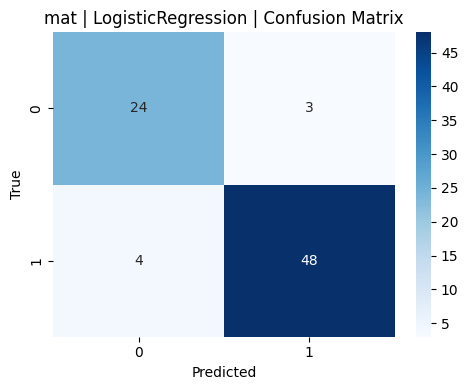

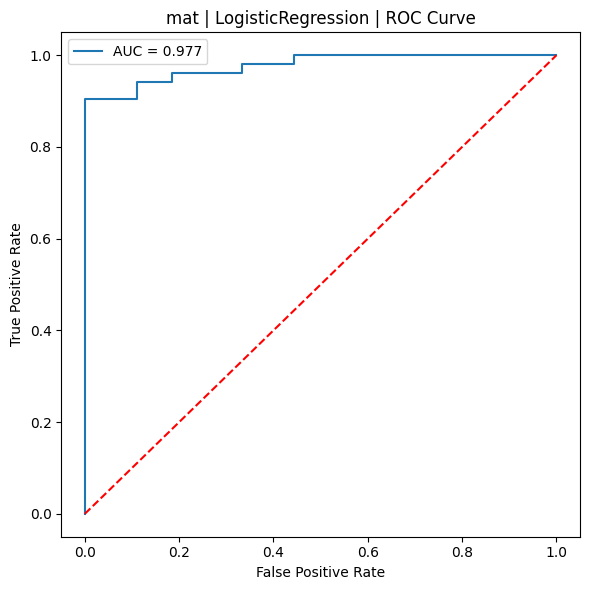

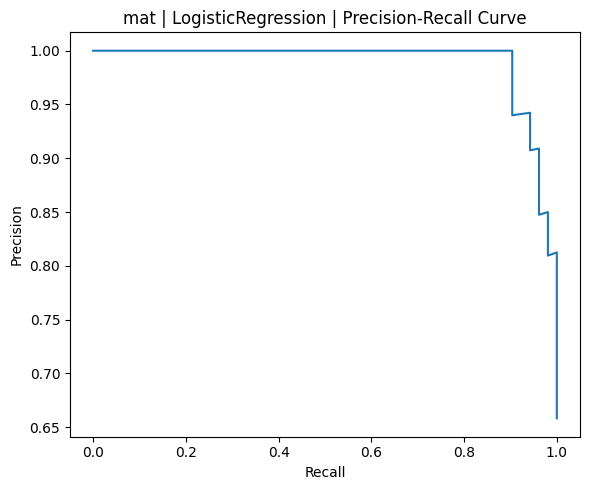

  - Training RandomForestClassifier ...


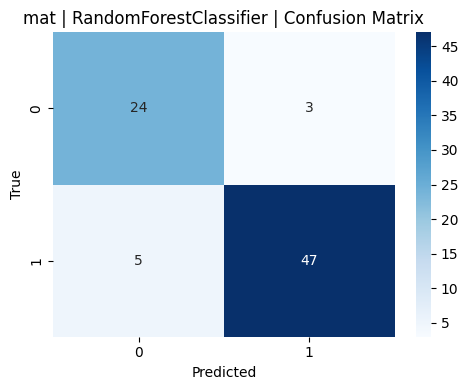

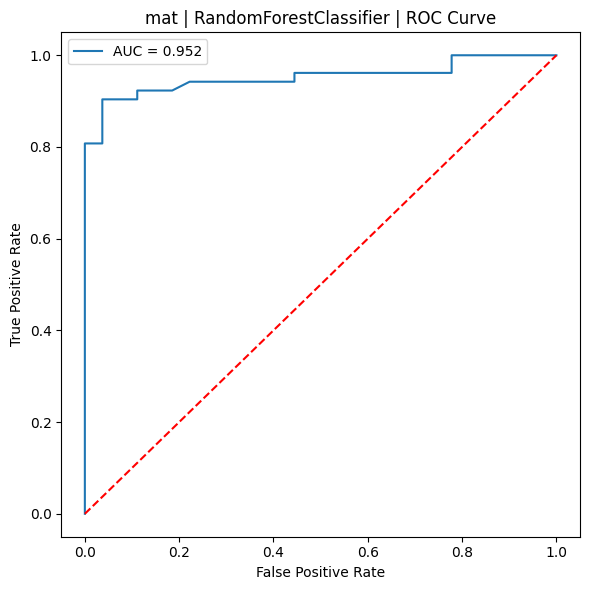

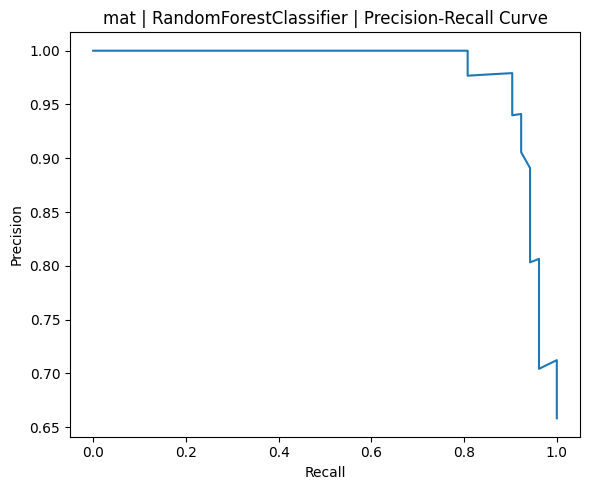

  - Training XGBClassifier ...


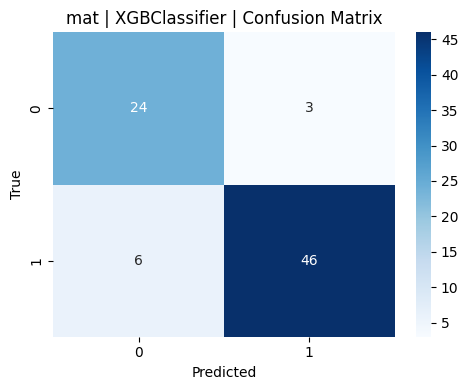

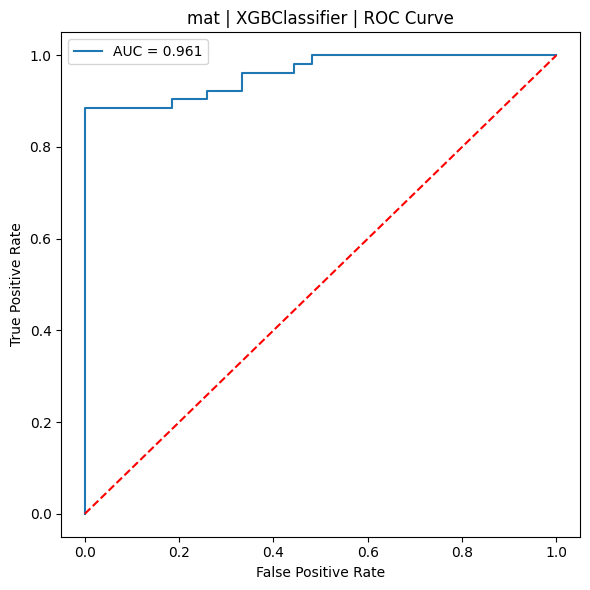

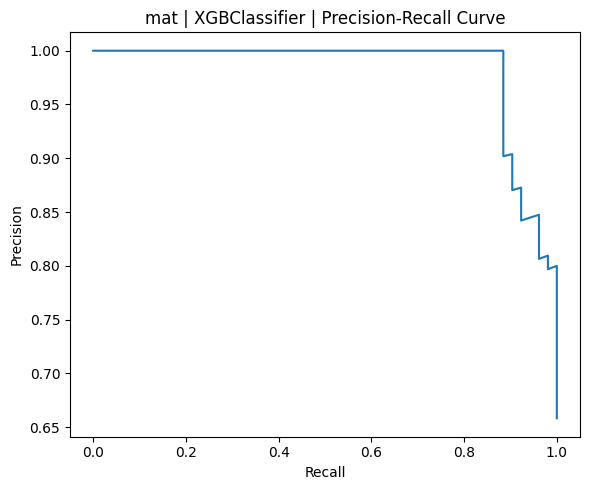


### Dataset: por ###
  - Training LogisticRegression ...


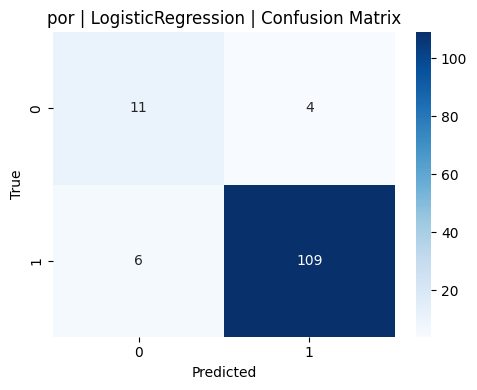

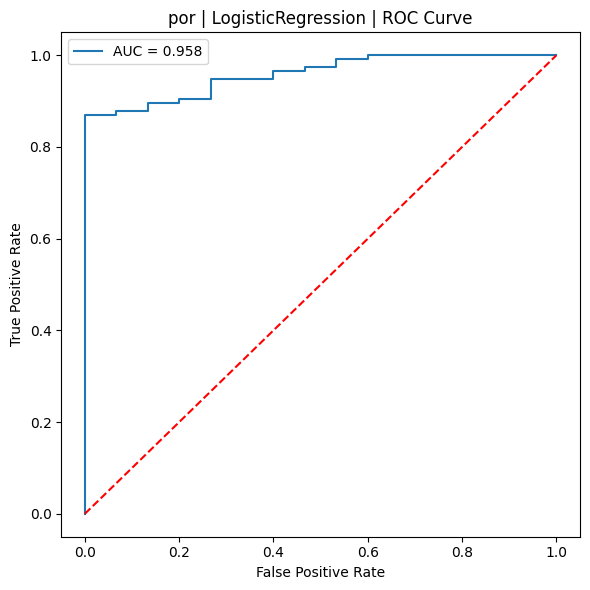

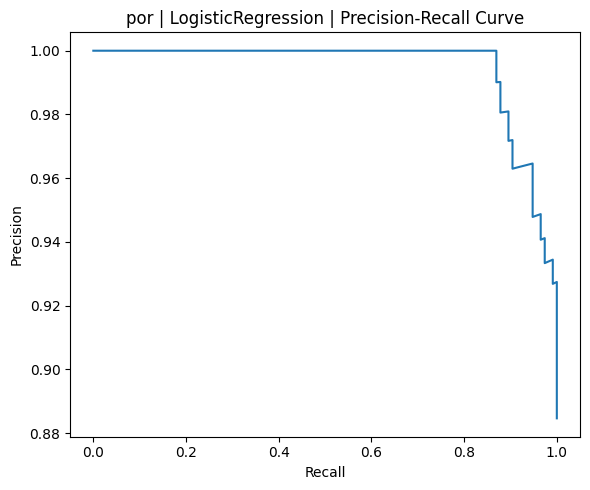

  - Training RandomForestClassifier ...


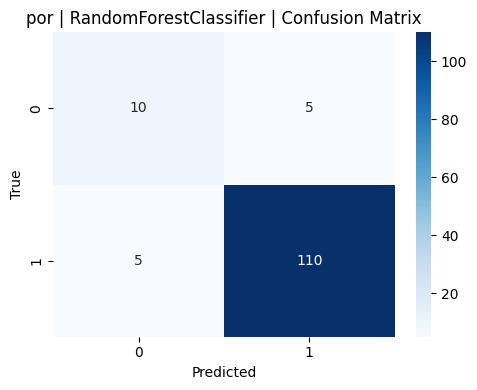

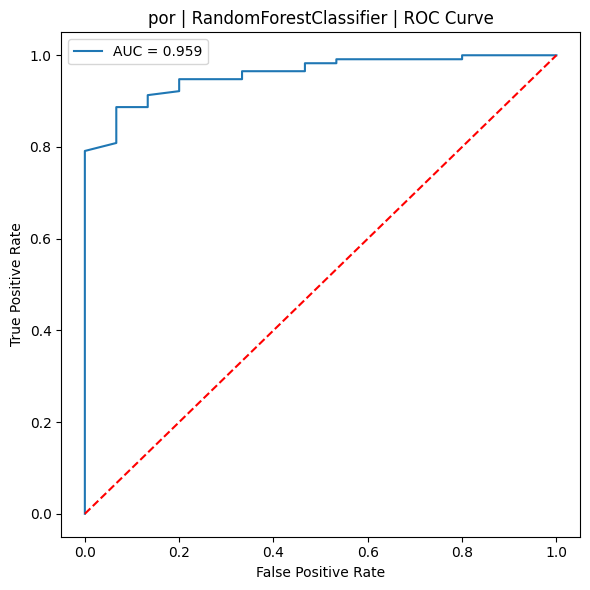

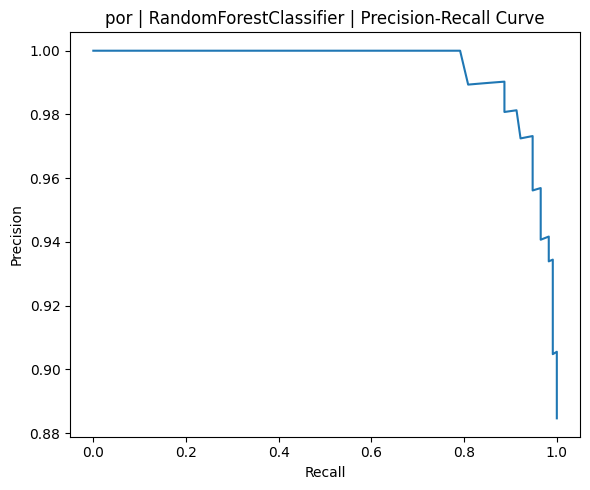

  - Training XGBClassifier ...


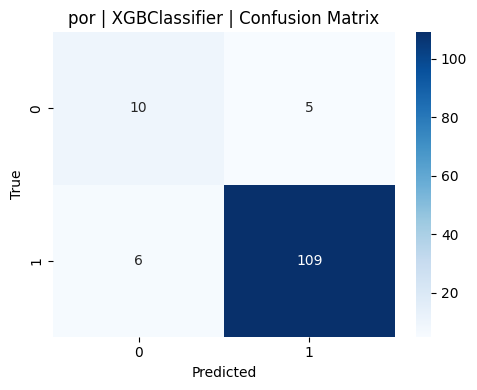

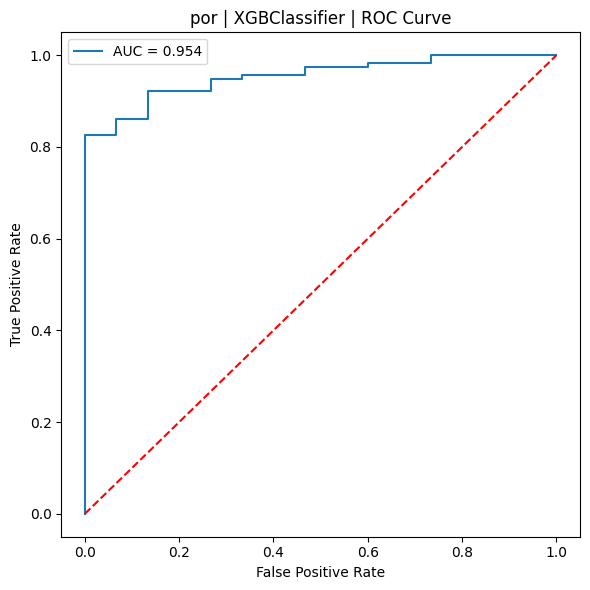

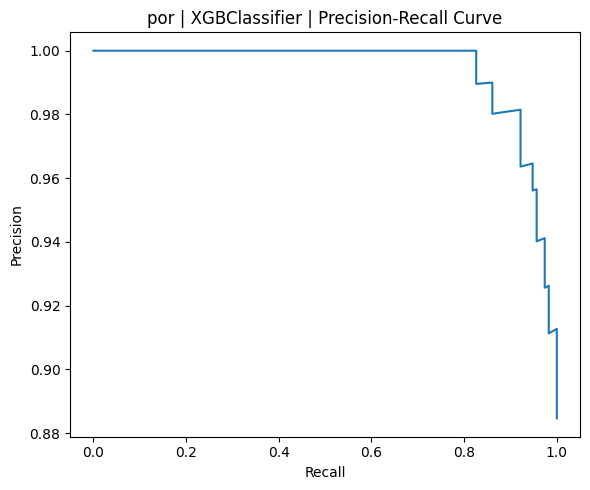


===== Classification Summary =====



,dataset,model,Accuracy,Precision,Recall,F1,AUC,CV_Mean_Accuracy,CV_STD_Accuracy
0,mat,LogisticRegression,0.911,0.941,0.923,0.932,0.977,0.919,0.031
1,mat,RandomForestClassifier,0.899,0.940,0.904,0.922,0.952,0.906,0.017
2,mat,XGBClassifier,0.886,0.939,0.885,0.911,0.961,0.909,0.019
3,por,LogisticRegression,0.923,0.965,0.948,0.956,0.958,0.904,0.028
4,por,RandomForestClassifier,0.923,0.957,0.957,0.957,0.959,0.914,0.019
5,por,XGBClassifier,0.915,0.956,0.948,0.952,0.954,0.911,0.031


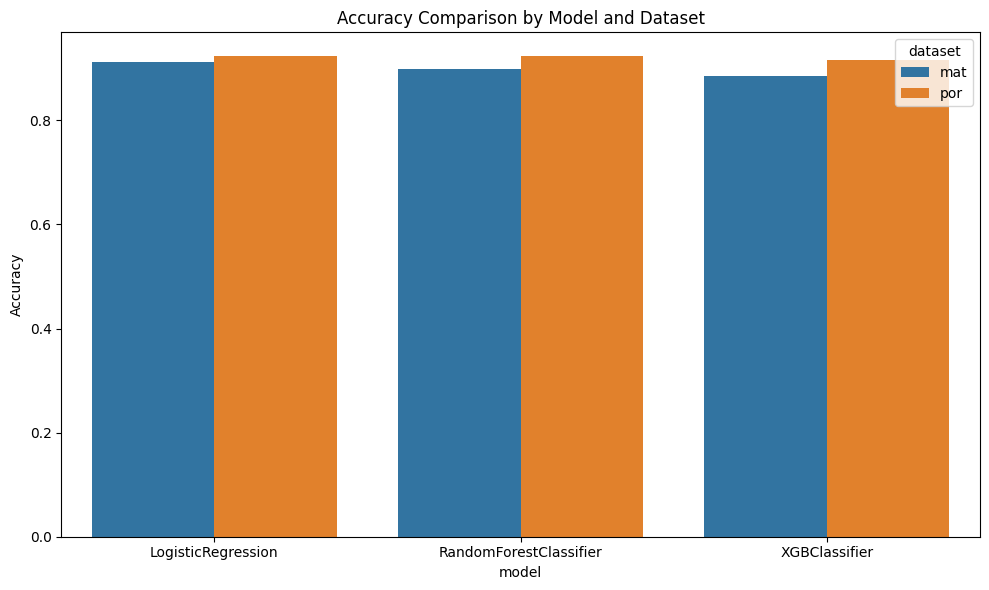

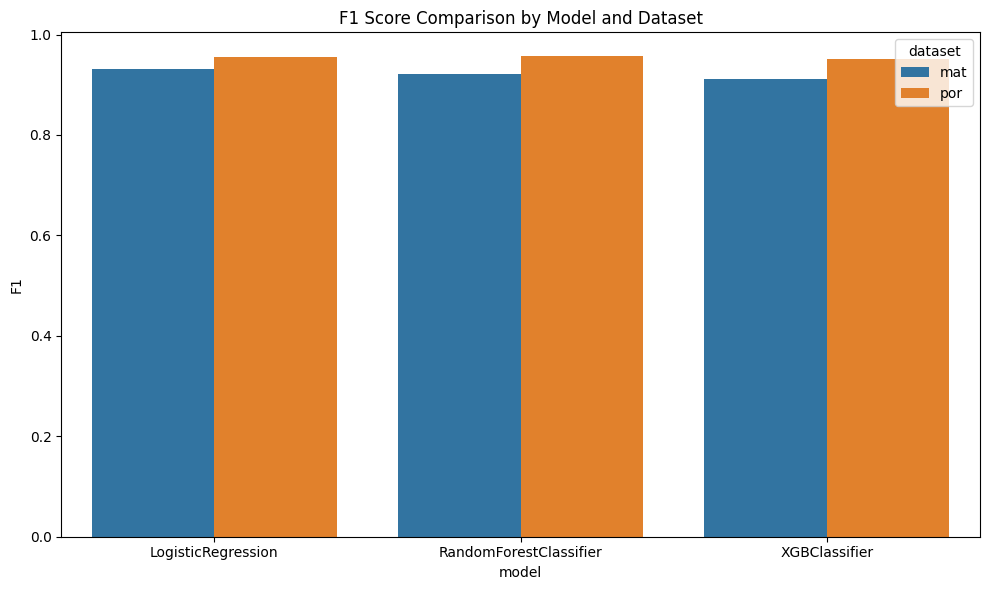

In [13]:
# Orchestrate training/eval across datasets and return results
def main() -> pd.DataFrame:  # pipeline entrypoint
    models = get_models()  # fetch model dictionary

    processed_datasets = {
        "mat": load_processed("mat"),  # processed math features
        "por": load_processed("por"),  # processed Portuguese features
    }  # processed data cache
    raw_datasets = {
        "mat": load_raw("mat"),  # raw math data
        "por": load_raw("por"),  # raw Portuguese data
    }  # raw data cache

    all_results = []  # collected run results

    for dataset_name in ["mat", "por"]:  # iterate datasets
        df_proc = processed_datasets[dataset_name]  # select processed
        df_raw = raw_datasets[dataset_name]  # select raw

        print(f"\n### Dataset: {dataset_name} ###")  # progress log

        for model_name, model in models.items():  # iterate models
            print(f"  - Training {model_name} ...")  # log model
            result = train_single_model(df_proc, df_raw, model_name, model, dataset_name)  # fit/eval
            all_results.append(result)  # store result

            plot_confusion(result, PLOTS_DIR)  # save confusion plot
            plot_roc_curve(result, PLOTS_DIR)  # save ROC plot
            plot_pr_curve(result, PLOTS_DIR)  # save PR plot

    results_df = pd.DataFrame(all_results)  # aggregate results
    plot_summary(results_df, PLOTS_DIR)  # summary plots/tables
    return results_df  # return dataframe


if __name__ == "__main__":  # script entry guard
    main()  # run pipeline
